# 1. Konfiguracja środowiska oraz datasetu

## 1.1. Instalacja zależności

In [1]:
#%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
#%pip install -r requirements.txt

## 1.2.Konfiguracja importów

In [2]:
import torch
import random
from pathlib import Path
from IPython.display import Audio
from src.process_guitarset import process_dataset
from src.config import *
from src.dataset import GuitarSetDataset, collate_fn
from torch.utils.data import DataLoader
from src.model import TranscriptionModel
from src.train import run_training
from src.model_validate import evaluate_model_classification
from src.model_validate import visualize_predictions
from src.visualization import (
    plot_audio_waveform,
    plot_cqt,
    plot_annotation_map,
    create_annotation_maps
)

## 1.3. Konfiguracja GPU - automatyczne wykrywanie

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Używane urządzenie: {device}")
if device.type == 'cuda':
    print(f"Model karty GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True

Używane urządzenie: cpu


## 1.4. Wczytanie guitarsetu

In [4]:
config = {
    "data_dir": "src/guitarset_data",
    "output_dir": "src/processed_data",
    "seed": 42,
    "apply_augmentation": False,
    "max_tracks": None,
    "overwrite": False
}

process_dataset(**config)

Katalog wyjściowy 'src\processed_data' już istnieje. Pomijam przetwarzanie.


## 1.5. Wczytanie guitarseta z plików batch

In [5]:
# Wczytanie danych z plików
train_dir = Path(config["output_dir"]) / "train"
val_dir = Path(config["output_dir"]) / "val"
test_dir = Path(config["output_dir"]) / "test"

train_dataset = GuitarSetDataset(train_dir)
val_dataset = GuitarSetDataset(val_dir)
test_dataset = GuitarSetDataset(test_dir)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=4
)

## 1.6. Wizualizacja przykładowego pliku

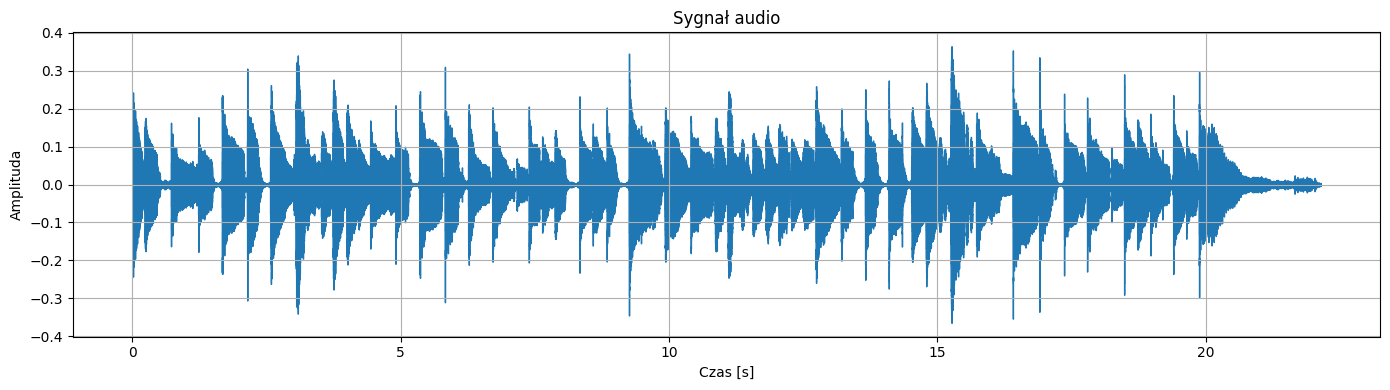

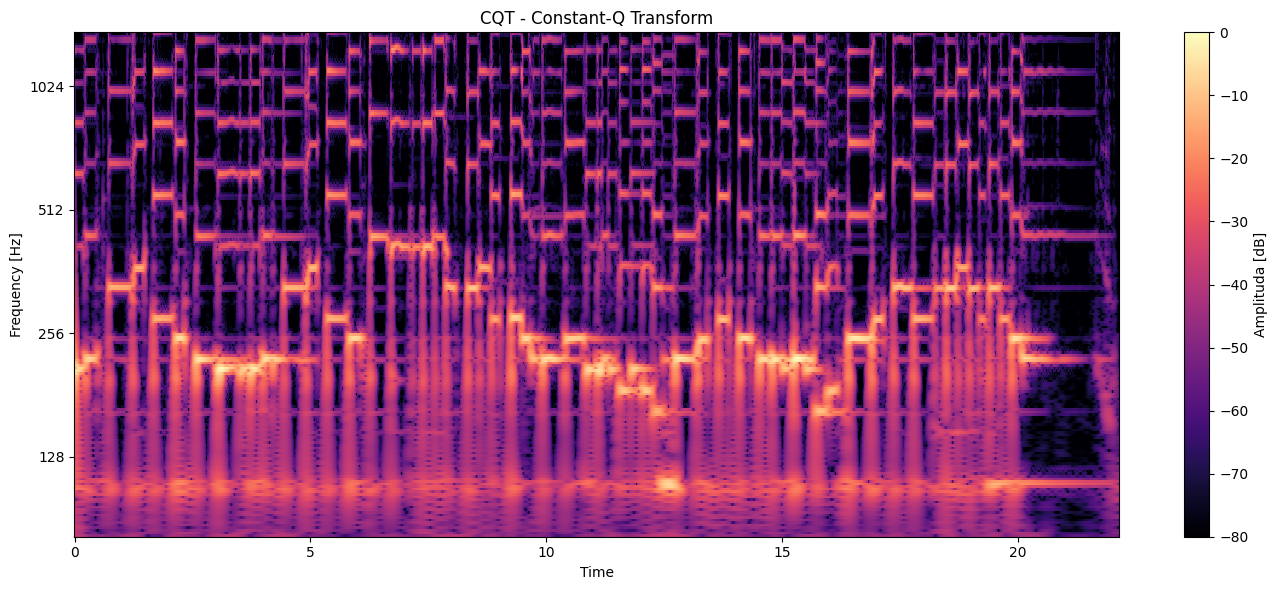

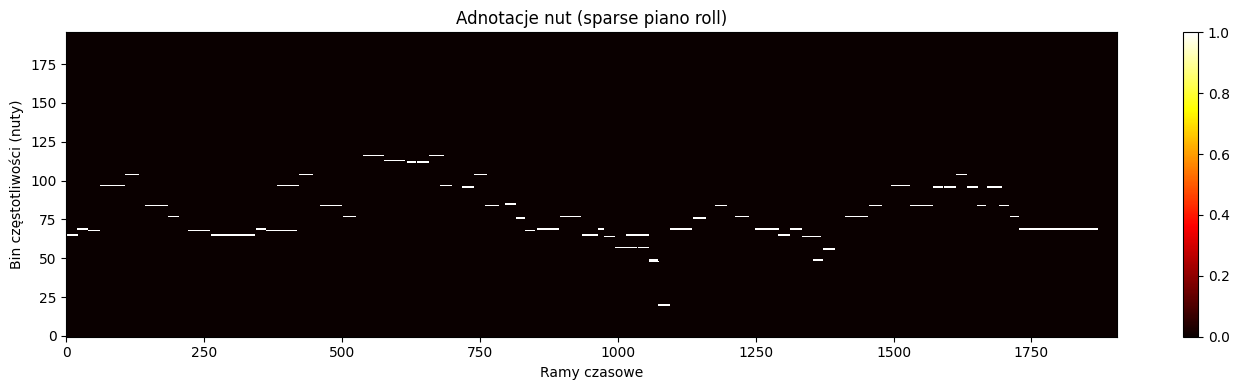

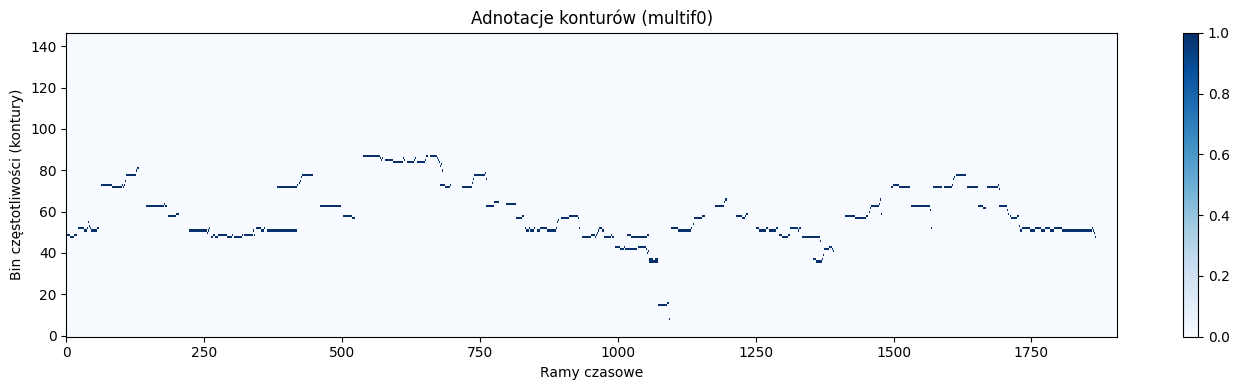

In [6]:
sample = random.choice(train_dataset)

# Dane surowe
audio = sample["audio"].numpy()
cqt = sample["features"].numpy()
sr = sample["sample_rate"]

# Wizualizacja audio i CQT
plot_audio_waveform(audio, sr)
plot_cqt(cqt, sr=AUDIO_SAMPLE_RATE, hop_length=FFT_HOP,
         freq_bins=FREQ_BINS_NOTES)

# Wizualizacja adnotacji nut i konturów
notes_map, contours_map = create_annotation_maps(sample)
plot_annotation_map(notes_map, title="Adnotacje nut (sparse piano roll)", ylabel="Bin częstotliwości (nuty)",
                    cmap='hot')
plot_annotation_map(contours_map, title="Adnotacje konturów (multif0)", ylabel="Bin częstotliwości (kontury)",
                    cmap='Blues')
# Odtwarzanie audio
Audio(audio, rate=sr)


# 2. Model i uczenie

## 2.1. Wczytanie implementacji modelu

In [7]:
sample = next(iter(train_loader))
input_features = sample["features"].shape[-1]
model = TranscriptionModel(n_freq_bins=input_features)

## 2.2. Pętla treningowa

In [8]:
#run_training(model, train_loader, val_loader, device=device, epochs=150)

## 2.3. Badanie metryk modelu

In [9]:
# Wczytanie modelu z pliku
model.load_state_dict(torch.load("best_model.pt", map_location=device, weights_only=True))
model = model.to(device)

#evaluate_model_classification(model, test_loader, device)

## 2.4. Wizualizacja wyników testu

C:\Users\lukig\Documents\Programming\music-transcription\python\src\model_validate.py:76: UserWarning: Glyph 127932 (\N{MUSICAL SCORE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lukig\Documents\Programming\music-transcription\python\src\model_validate.py:76: UserWarning: Glyph 127911 (\N{HEADPHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lukig\Documents\Programming\music-transcription\python\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127932 (\N{MUSICAL SCORE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lukig\Documents\Programming\music-transcription\python\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127911 (\N{HEADPHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


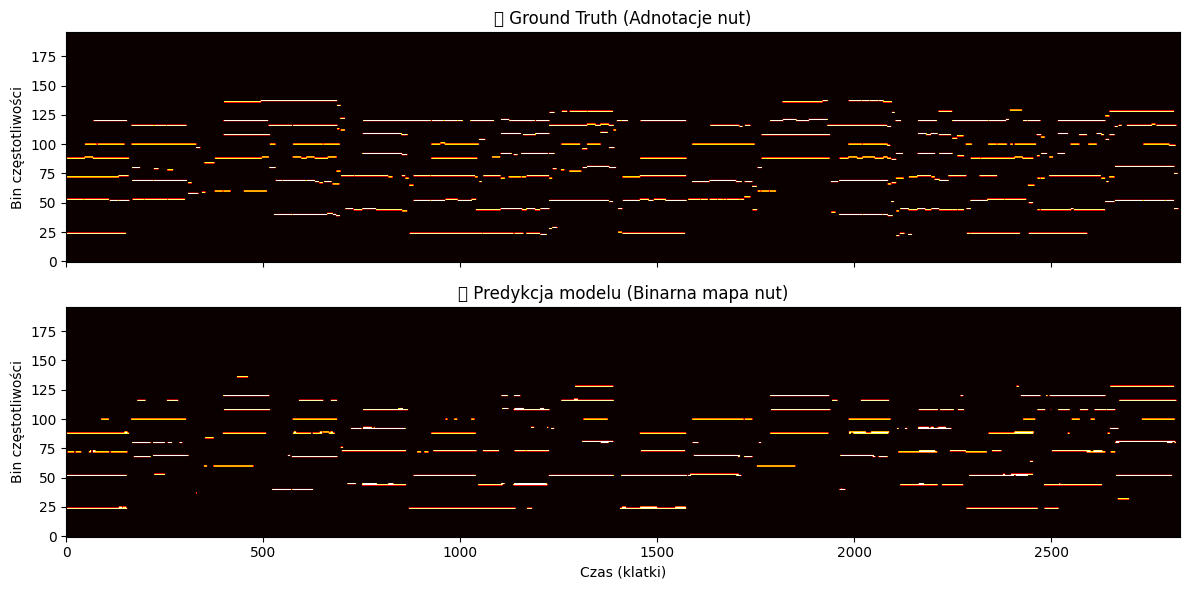

In [10]:
visualize_predictions(model, test_dataset, device, index=5)